# **THỰC HIỆN THỐNG KÊ MÔ TẢ TRÊN TẬP DỮ LIỆU VỀ BỆNH TIỂU ĐƯỜNG.**

## Import thư viện

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Tải dữ liệu lên

In [21]:
data = pd.read_csv("diabetes.csv")
data.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72.0,35.0,0.0,33.6,0.627,50,1
1,1,85,66.0,29.0,NaN,26.6,0.351,31,0
2,8,183,64.0,0.0,0.0,23.3,0.672,32,1
3,1,89,66.0,23.0,94.0,28.1,0.167,21,0
4,0,137,40.0,35.0,168.0,43.1,2.288,33,1


## Thống kê mô tả

### Hiển thị số dòng và số cột của dữ liệu

In [22]:
# so dong, so cot cua du lieu
print(f'Số dòng, số cột của dữ liệu: ', data.shape)

Số dòng, số cột của dữ liệu:  (770, 9)


**Nhận xét:** Bộ dữ liệu "diabetes.csv" có 9 đặc trưng và 770 dòng dữ liệu.

### Hiển thị kiểu dữ liệu

In [23]:
# kieu du lieu cua tung cot
print(f'Kiểu dữ liệu của từng cột:\n',data.dtypes)

Kiểu dữ liệu của từng cột:
 Pregnancies                   int64
Glucose                       int64
BloodPressure               float64
SkinThickness               float64
Insulin                     float64
BMI                         float64
DiabetesPedigreeFunction    float64
Age                           int64
Outcome                       int64
dtype: object


**Nhận xét:** Hầu hết các biến đặc trưng đều có kiểu int hoặc float, điều này giúp cho việc thống kê mô tả trở nên nhanh, chính xác và hiệu quả hơn.

### Hiển thị 5 dòng đầu và 5 dòng cuối của dữ liệu

In [24]:
# hien thi 5 dong dau va 5 dong cuoi 
display(data.head(5))
display(data.tail(5))

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72.0,35.0,0.0,33.6,0.627,50,1
1,1,85,66.0,29.0,NaN,26.6,0.351,31,0
2,8,183,64.0,0.0,0.0,23.3,0.672,32,1
3,1,89,66.0,23.0,94.0,28.1,0.167,21,0
4,0,137,40.0,35.0,168.0,43.1,2.288,33,1


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
765,5,121,72.0,23.0,112.0,26.2,0.245,30,0
766,1,126,60.0,0.0,0.0,30.1,0.349,47,1
767,1,93,70.0,31.0,0.0,30.4,0.315,23,0
768,10,168,74.0,0.0,0.0,38.0,0.537,34,1
769,1,115,70.0,30.0,96.0,34.6,0.529,32,1


### Hiển thị thông tin chung về dữ liệu

In [25]:
# thong tin chung ve du lieu
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 770 entries, 0 to 769
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               770 non-null    int64  
 1   Glucose                   770 non-null    int64  
 2   BloodPressure             768 non-null    float64
 3   SkinThickness             768 non-null    float64
 4   Insulin                   765 non-null    float64
 5   BMI                       769 non-null    float64
 6   DiabetesPedigreeFunction  770 non-null    float64
 7   Age                       770 non-null    int64  
 8   Outcome                   770 non-null    int64  
dtypes: float64(5), int64(4)
memory usage: 54.3 KB


**Nhận xét:** Nhiều đặc trưng trong tập dữ liệu có giá trị thiếu, các đặc trưng đó bao gồm: "BloodPressure", "SkinThickness", "Insulin", "BMI".

In [26]:
data_copy = data.copy() # tạo bản sao tập dữ liệu

### Kiểm tra tính toàn vẹn của dữ liệu

* Kiểm tra dữ liệu trùng lặp

In [27]:
# Kiem tra du lieu trùng lặp
data_dup = data_copy[data_copy.duplicated(keep=False)]
if not data_dup.empty:
    print('Số hàng trùng nhau: ', data_dup.shape[0])
    display(data_dup)
else:
    print('Không có hàng nào trùng nhau.')


Số hàng trùng nhau:  4


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
11,10,168,74.0,0.0,0.0,38.0,0.537,34,1
19,1,115,70.0,30.0,96.0,34.6,0.529,32,1
768,10,168,74.0,0.0,0.0,38.0,0.537,34,1
769,1,115,70.0,30.0,96.0,34.6,0.529,32,1


**Nhận xét:** Số dòng trùng lặp là 4, tức là có 2 dòng trùng với 2 dòng khác trong tập dữ liệu, số lượng dòng trùng lặp rất nhỏ, không ảnh hưởng gì đến tập dữ liệu khi xử lý.

* Kiểm tra giá trị null/nan

In [28]:
# Kiem tra du lieu Null

#data_copy.isnull().sum().any() # ktra xem trong toan bo df co bat ky gtri null nao khong
#df.isnull().values.any() #ktra xem co gia tri null khong
#total_null = df.isnull().sum().sum() # dem tong so gia tri null
#df.isnull().sum() # dem so luong null theo tung cot

data_null = data_copy[data_copy.isnull().any(axis=1)]
if not data_null.empty:
    print('Số lượng dòng chứa giá trị null: ', data_null.shape[0])
    display(data_null)
    print("Số lượng giá trị null theo từng cột:")
    print(data_copy.isnull().sum())
else:
    print('Không có giá trị null nào.')

Số lượng dòng chứa giá trị null:  10


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
1,1,85,66.0,29.0,NaN,26.6,0.351,31,0
7,10,115,NaN,0.0,0.0,35.3,0.134,29,0
9,8,125,96.0,0.0,0.0,NaN,0.232,54,1
10,4,110,92.0,0.0,NaN,37.6,0.191,30,0
15,7,100,NaN,0.0,0.0,30.0,0.484,32,1
46,1,146,56.0,NaN,0.0,29.7,0.564,29,0
78,0,131,0.0,NaN,0.0,43.2,0.270,26,1
131,9,122,56.0,0.0,NaN,33.3,1.114,33,1
172,2,87,0.0,23.0,NaN,28.9,0.773,25,0
178,5,143,78.0,0.0,NaN,45.0,0.190,47,0


Số lượng giá trị null theo từng cột:
Pregnancies                 0
Glucose                     0
BloodPressure               2
SkinThickness               2
Insulin                     5
BMI                         1
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


**Nhận xét:** Các dữ liệu thiếu tập trung ở đặc trưng Insulin là nhiều nhất với 5 giá trị thiếu, còn lại các đặc trưng khác như "BloodPressure", "SkinThickness", "BMI" thì chỉ có 1 đến 2 giá trị thiếu.

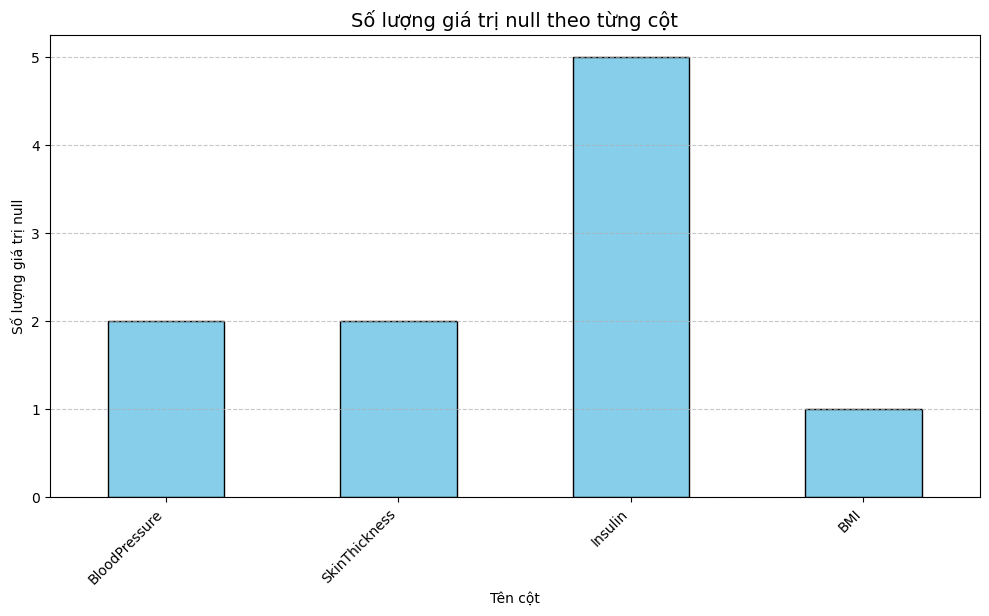

In [29]:
# Truc quan du lieu null
# cach 1: bieu do cot the hien so luong gia tri null moi cot
missing = data_copy.isnull().sum()

missing = missing[missing > 0] # chỉ hiển thị các cột có ít nhất 1 gtri null

missing.plot(kind='bar', color='skyblue', edgecolor = 'black', figsize=(12,6))

plt.title('Số lượng giá trị null theo từng cột', fontsize = 14)
plt.ylabel('Số lượng giá trị null')
plt.xlabel('Tên cột')
plt.xticks(rotation = 45, ha = 'right')
plt.grid(axis='y', linestyle = '--', alpha = 0.7)

plt.show()

**Nhận xét:** Biểu đồ cột trực quan số lượng giá trị thiếu ở các đặc trưng.

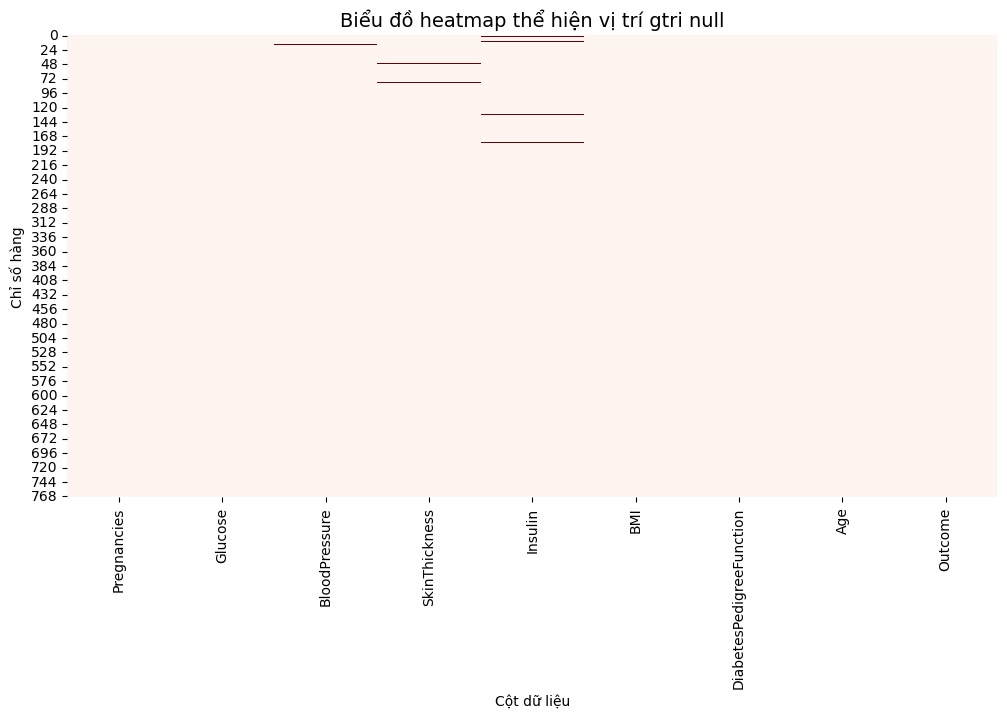

In [30]:
# Cach 2: Bieu do heatmap (ban do nhiet) de xem vi tri null
plt.figure(figsize=(12,6))
sns.heatmap(data_copy.isnull(), cmap = 'Reds', cbar = False)

plt.title('Biểu đồ heatmap thể hiện vị trí gtri null', fontsize = 14)
plt.xlabel('Cột dữ liệu')
plt.ylabel('Chỉ số hàng')
plt.show()

**Nhận xét:** Biểu đồ heatmap trực quan vị trị các giá trị thiếu ở các đặc trưng, với đường gạch đỏ là vị trí có giá trị thiếu.

* Xứ lý các giá trị trùng lặp

In [31]:
#Xử lý giá trị dup
#data_copy = data_copy.drop_duplicates(keep='first')
data_copy.drop_duplicates(inplace=True)

#Kiem tra lai gtri dup
print(data_copy.duplicated().sum().any())

False


**Nhận xét:** Tiến hành xử lý các giá trị trùng lặp và kiểm tra lại xem tập dữ liệu có còn dữ liệu bị trùng lặp nữa không.

* Xử lý các giá trị null/nan

In [32]:
# Xử lý giá trị null
#data_copy.dropna() #Loại bỏ các dòng chứa giá trị null
data_copy = data_copy.fillna(0) #thay gia trị null = 0
#data_copy = data_copy.fillna(data_copy.mean())

# Ktra lai gtri null
print(data_copy.isnull().sum().any())

False


**Nhận xét:** Tiến hành xử lý các giá trị thiếu và kiểm tra lại xem tập dữ liệu có còn dữ liệu bị thiếu nữa không.

### Hiển thị các tính chất thống kê trên dữ liệu số

In [33]:
#Cac tinh chat thong ke tren du lieu so
description = data_copy.describe().T
display(description)

,count,mean,std,min,25%,50%,75%,max
Pregnancies,768.0,3.845052,3.369578,0.000,1.00000,3.0000,6.00000,17.00
Glucose,768.0,120.894531,31.972618,0.000,99.00000,117.0000,140.25000,199.00
BloodPressure,768.0,69.105469,19.355807,0.000,62.00000,72.0000,80.00000,122.00
SkinThickness,768.0,20.536458,15.952218,0.000,0.00000,23.0000,32.00000,99.00
Insulin,768.0,79.799479,115.244002,0.000,0.00000,30.5000,127.25000,846.00
BMI,768.0,31.992578,7.884160,0.000,27.30000,32.0000,36.60000,67.10
DiabetesPedigreeFunction,768.0,0.471876,0.331329,0.078,0.24375,0.3725,0.62625,2.42
Age,768.0,33.240885,11.760232,21.000,24.00000,29.0000,41.00000,81.00
Outcome,768.0,0.348958,0.476951,0.000,0.00000,0.0000,1.00000,1.00


**Nhận xét:**
* Sau khi xử lý các dòng trùng lặp và các giá trị thiếu thì số lượng dòng trong tập dữ liệu là 768 dòng.
* Đặc trưng Insulin có độ lệch chuẩn rất lớn, cho thấy đặc trưng có giá trị rất phân tán.
* Hầu hết các đặc trưng ngoại trừ "Insulin" có mean ≈ median(50%) cho thấy dữ liệu tương đối tương xứng.
* Biến mục tiêu (Outcome) có giá trị từ 0-1 và đa số là giá trị 0.

### Hiển thị dữ liệu trên từng tính chất đơn

* **Box and whisker plots**

<Axes: >

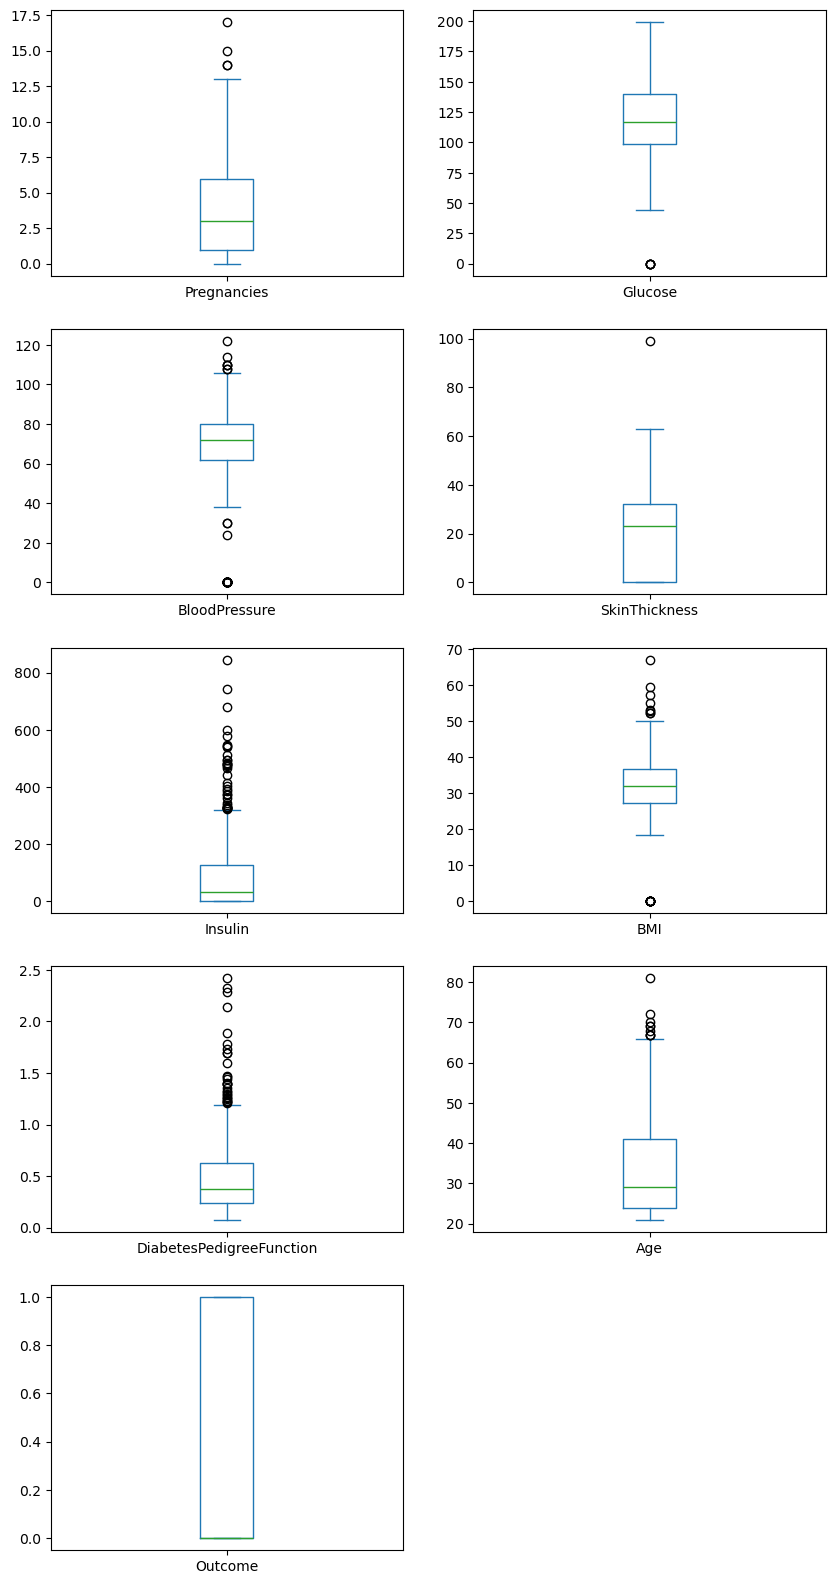

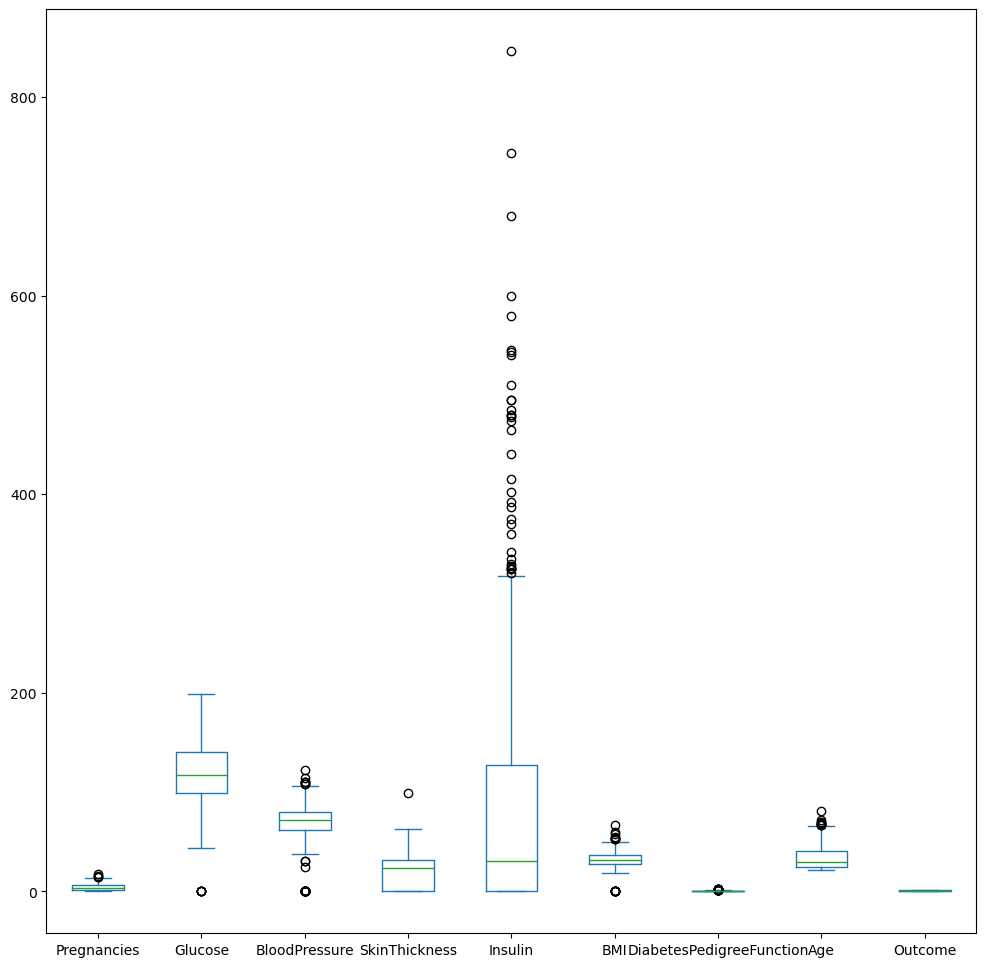

In [34]:
data_copy.plot(kind="box", subplots=True, layout=(5, 2), sharex=False, sharey=False, figsize=(10,20))
data_copy.plot(kind='box', figsize=(12,12))

* **Histogram**

array([[<Axes: title={'center': 'Pregnancies'}>,
        <Axes: title={'center': 'Glucose'}>,
        <Axes: title={'center': 'BloodPressure'}>],
       [<Axes: title={'center': 'SkinThickness'}>,
        <Axes: title={'center': 'Insulin'}>,
        <Axes: title={'center': 'BMI'}>],
       [<Axes: title={'center': 'DiabetesPedigreeFunction'}>,
        <Axes: title={'center': 'Age'}>,
        <Axes: title={'center': 'Outcome'}>]], dtype=object)

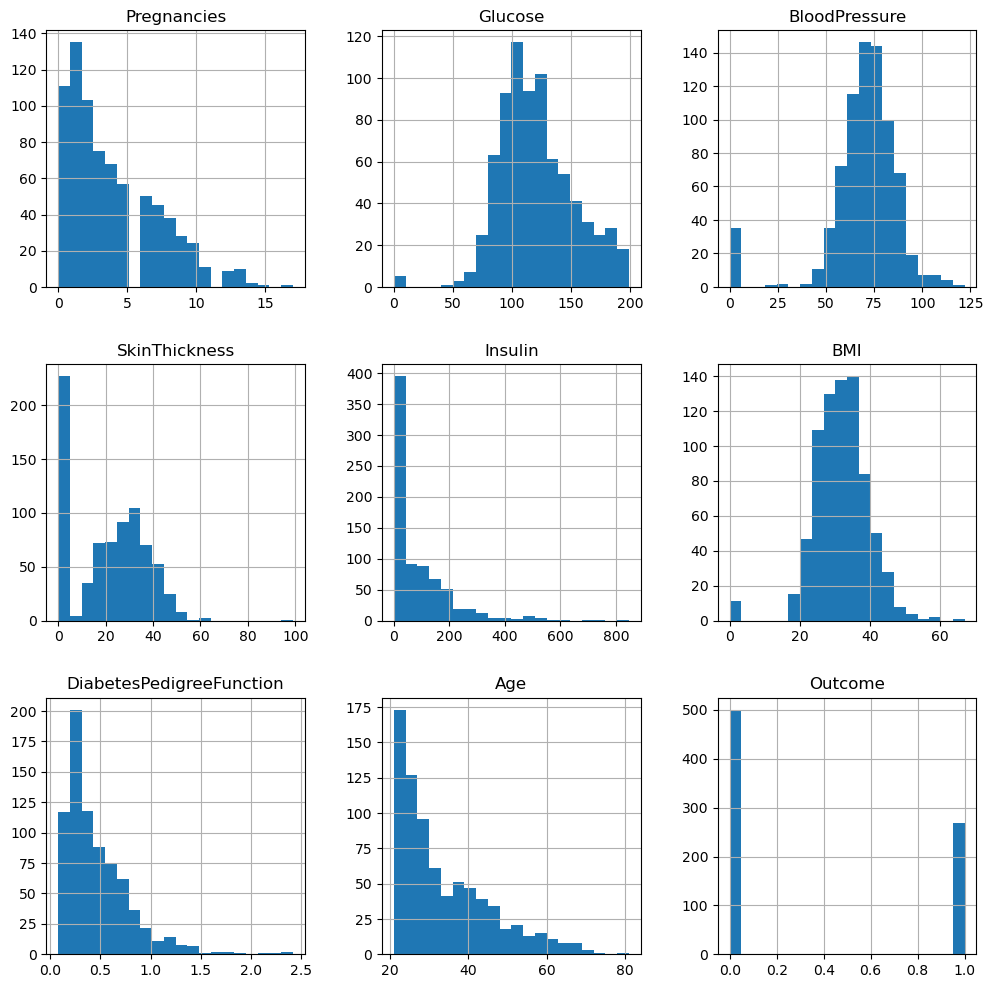

In [35]:
data_copy.hist(figsize=(12, 12), bins = 20, sharex= False, sharey= False)

### Hiển thị nhiều tính chất của dữ liệu

array([[<Axes: xlabel='Pregnancies', ylabel='Pregnancies'>,
        <Axes: xlabel='Glucose', ylabel='Pregnancies'>,
        <Axes: xlabel='BloodPressure', ylabel='Pregnancies'>,
        <Axes: xlabel='SkinThickness', ylabel='Pregnancies'>,
        <Axes: xlabel='Insulin', ylabel='Pregnancies'>,
        <Axes: xlabel='BMI', ylabel='Pregnancies'>,
        <Axes: xlabel='DiabetesPedigreeFunction', ylabel='Pregnancies'>,
        <Axes: xlabel='Age', ylabel='Pregnancies'>,
        <Axes: xlabel='Outcome', ylabel='Pregnancies'>],
       [<Axes: xlabel='Pregnancies', ylabel='Glucose'>,
        <Axes: xlabel='Glucose', ylabel='Glucose'>,
        <Axes: xlabel='BloodPressure', ylabel='Glucose'>,
        <Axes: xlabel='SkinThickness', ylabel='Glucose'>,
        <Axes: xlabel='Insulin', ylabel='Glucose'>,
        <Axes: xlabel='BMI', ylabel='Glucose'>,
        <Axes: xlabel='DiabetesPedigreeFunction', ylabel='Glucose'>,
        <Axes: xlabel='Age', ylabel='Glucose'>,
        <Axes: xlabel='Outcom

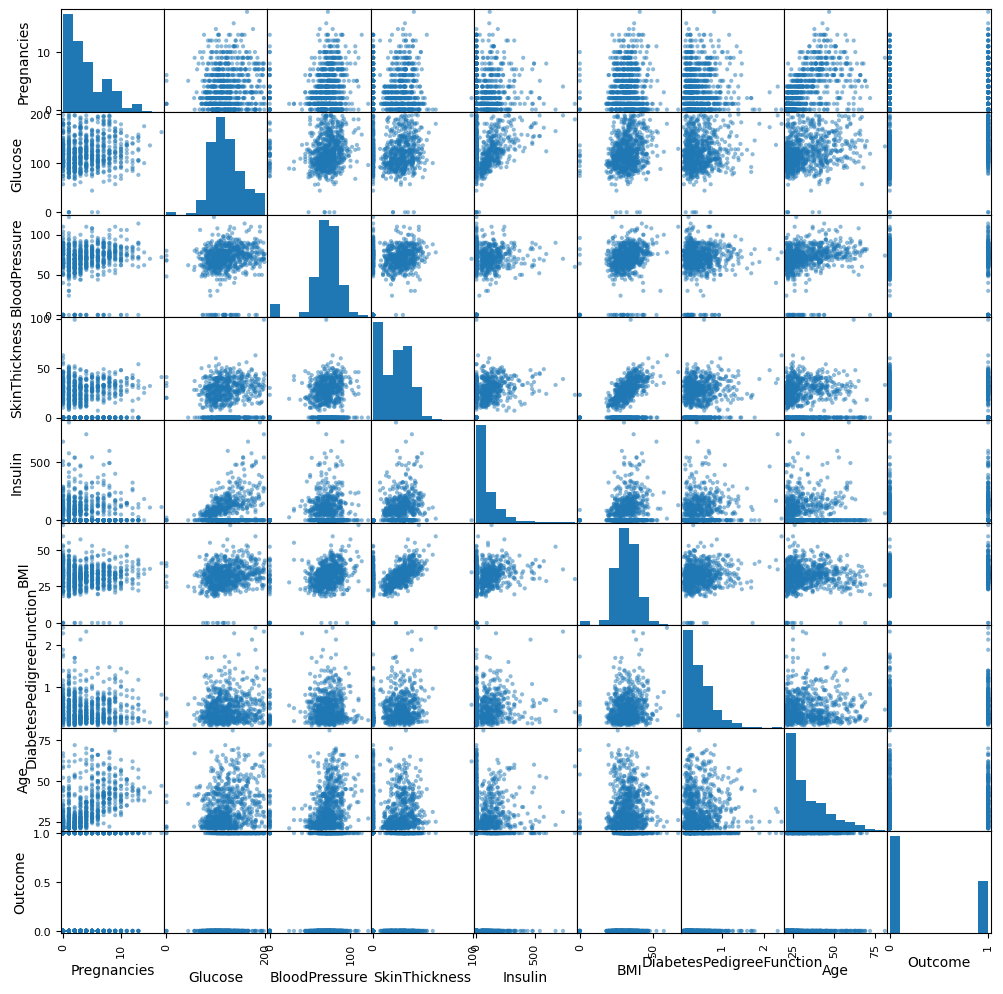

In [36]:
pd.plotting.scatter_matrix(data_copy, figsize=(12, 12))

### Mối tương quan giữa các đặc trưng

In [38]:
correlations = data_copy.corr(method = 'pearson')
display(correlations)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
Pregnancies,1.000000,0.129459,0.141282,-0.081672,-0.073535,0.017683,-0.033523,0.544341,0.221898
Glucose,0.129459,1.000000,0.152590,0.057328,0.331357,0.221071,0.137337,0.263514,0.466581
BloodPressure,0.141282,0.152590,1.000000,0.207371,0.088933,0.281805,0.041265,0.239528,0.065068
SkinThickness,-0.081672,0.057328,0.207371,1.000000,0.436783,0.392573,0.183928,-0.113970,0.074752
Insulin,-0.073535,0.331357,0.088933,0.436783,1.000000,0.197859,0.185071,-0.042163,0.130548
BMI,0.017683,0.221071,0.281805,0.392573,0.197859,1.000000,0.140647,0.036242,0.292695
DiabetesPedigreeFunction,-0.033523,0.137337,0.041265,0.183928,0.185071,0.140647,1.000000,0.033561,0.173844
Age,0.544341,0.263514,0.239528,-0.113970,-0.042163,0.036242,0.033561,1.000000,0.238356
Outcome,0.221898,0.466581,0.065068,0.074752,0.130548,0.292695,0.173844,0.238356,1.000000


* Biểu đồ heatmap trực quan sự tương quan giữa các biến với nhau

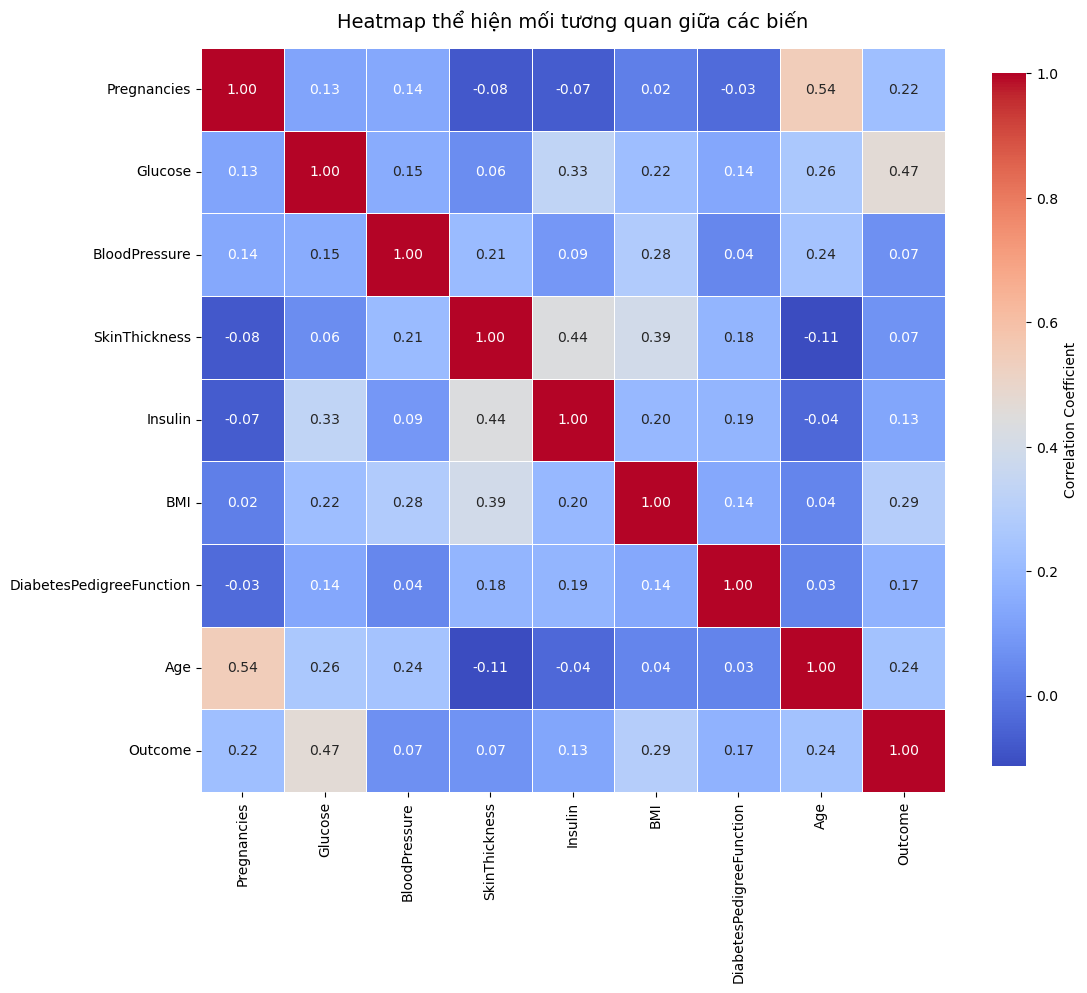

In [39]:
plt.figure(figsize=(12,12))
sns.heatmap(
    correlations,
    annot=True, #hien thi gtri tren cac o
    fmt = ".2f", #lam tron 2 chu so thap phan
    cmap = "coolwarm", #bang mau 
    linewidths=0.5, #khoang cach giua cac o
    square=True, # hien thi o vuong cho dep
    cbar_kws={"shrink": 0.75, "label": "Correlation Coefficient"} #thanh mau ben phai
)
plt.title("Heatmap thể hiện mối tương quan giữa các biến", fontsize = 14, pad=15)
plt.show()